# Preparing the GLOBMAP Global Leaf Area Index (LAI) Dataset Since 1981

The GLOBMAP global Leaf Area Index (LAI) dataset is published on [Zenodo](https://zenodo.org/records/12698637) with one GeoTIFF file per year, and multiple years are sometimes packaged in RAR archives.

In this notebook, we prepare a **combined dataset** for use in the **xcube Multi-Source Data Store.** The workflow is as follows:

1. **Download and decompress** the yearly files using [xcube-zenodo](https://github.com/xcube-dev/xcube-zenodo).
2. **Stack the datasets along the time dimension** to create a 3D spatio-temporal data cube.
3. **Assign fill values and scale factors** so that the dataset can be stored efficiently as int16 dtype, and the fill value and scale are applied on the fly. 
4. **Store the complete data cube as Zarr** in the local Zenodo cache.

This preparation allows the GLOBMAP LAI dataset to be readily accessed and analyzed for spatio-temporal studies.

> NOTE: The Python package `rarfile` is used for handling RAR-compressed files. It requires an external decompression backend — such as `unrar` or `bsdtar` — to be installed on your system. For more details, see [here](https://github.com/xcube-dev/xcube-zenodo#access-compressed-datasets-and-datasets-published-as-netcdf-via-the-xcubes-preload-api)

---
## Imports and cluster setup

First we import everythin we need. 

In [1]:
import datetime
import re

import xarray as xr
from dask.distributed import Client, LocalCluster

from xcube.core.store import new_data_store

We create a local Dask cluster to constrain resource usage during the dataset preparation. 

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit="3GB",   # per worker
    dashboard_address=":8787"
)
client = Client(cluster)
client.dashboard_link

/home/yogesh/miniforge3/envs/eo-lincs-scs4/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38585 instead
  warnings.warn(


'http://127.0.0.1:38585/status'

----
## Preload datasets via xcube's Zenodo data store

Next, we create a Zenodo data store instance, which allows us to download and access the RAR files.

In [3]:
store = new_data_store("zenodo", root="12698637")

We will preload all data IDs containing TIFF files for the years 1991–2023.  
The next two cells will trigger the download and extraction of the `.rar` archives, each of which contains a TIFF file for every individual time slice.

In [4]:
data_ids = (
    '1991-2000_TIFF.rar',
    '2001-2005_TIFF.rar',
    '2006-2010_TIFF.rar',
    '2011-2015_TIFF.rar',
    '2016-2020_TIFF.rar',
    '2021-2023_TIFF.rar',
)

In [5]:
%%time
cache_store = store.preload_data(*data_ids)

Data ID,Status,Progress,Message,Exception
1991-2000_TIFF.rar,COMPLETED,100%,Preload finished,-
2001-2005_TIFF.rar,COMPLETED,100%,Preload finished,-
2006-2010_TIFF.rar,COMPLETED,100%,Preload finished,-
2011-2015_TIFF.rar,COMPLETED,100%,Preload finished,-
2016-2020_TIFF.rar,COMPLETED,100%,Preload finished,-
2021-2023_TIFF.rar,COMPLETED,100%,Preload finished,-


CPU times: user 42 s, sys: 1min 32s, total: 2min 14s
Wall time: 4min 49s


## Perform custom processing 

First, we sort the data IDs chronologically. 

In [6]:
data_ids = cache_store.list_data_ids()
data_ids = [data_id for data_id in data_ids if "_TIFF/GlobMapLAIV3" in data_id]
data_ids.sort()
data_ids

['1991-2000_TIFF/GlobMapLAIV3.A1991001.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991016.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991032.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991047.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991060.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991075.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991091.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991106.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991121.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991136.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991152.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991167.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991182.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991197.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991213.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991228.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991244.Global.LAI.tif',
 '1991-2000_TIFF/GlobMapLAIV3.A1991259.Global.LA

We read each time slice and concatenate them along the time dimension. While doing so, we extract the date from the data ID to build the time axis.

We apply a scaling factor of 0.01 and store it in the encoding field `scale_factor`. The dataset also contains values `-20` and `-100`, which are invalid pixels since the valid range is `0–1000`. We reassign `-20` to `-100`** and set `_FillValue` to `-100` in the encoding.

Furthermore, we set the dtype to `int16`** in the encoding. This ensures that the final Zarr dataset is stored as int16, with the fill value and scaling applied on the fly. This approach allows for efficient storage of the Zarr data cube as an integer dataset.

In [7]:
%%time
dss = []
dts = []
for data_id in data_ids:
    dss.append(cache_store.open_data(data_id, data_type="dataset"))
    match = re.search(r"A(\d{7})", data_id)
    date_str = match.group(1)
    dts.append(datetime.datetime.strptime(date_str, "%Y%j"))
ds = xr.concat(dss, dim="time")
ds = ds.assign_coords(dict(time=dts))
ds = ds.rename({"band_1": "lai", "y": "lat", "x": "lon"})
ds = ds.chunk(dict(time=1, lat=2091, lon=2475))

del ds.lai.encoding["grid_mapping"]
del ds.lai.attrs["scale_factor"]  
del ds.lai.attrs["add_offset"]

ds["lai"] = xr.where(ds.lai == -20, -100, ds.lai)
ds["lai"] = ds.lai.where(ds.lai != -100)
ds["lai"] = ds.lai * 0.01
ds.lai.encoding["_FillValue"] = -100 
ds.lai.encoding["scale_factor"] = 0.01 
ds.lai.encoding["add_offset"] = 0.0 
ds.lai.encoding["dtype"] = "int16"
ds.lai.attrs["units"] = "m2 m-2"
ds.lai.attrs["grid_mapping"] = "spatial_ref"

ds

CPU times: user 8.59 s, sys: 596 ms, total: 9.18 s
Wall time: 10.7 s


<xarray.Dataset> Size: 54GB
Dimensions:      (time: 1298, lat: 2091, lon: 4950)
Coordinates:
  * time         (time) datetime64[ns] 10kB 1991-01-01 1991-01-16 ... 2023-12-27
  * lat          (lat) float64 17kB 89.19 89.11 89.04 ... -62.67 -62.74 -62.81
  * lon          (lon) float64 40kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
    spatial_ref  int64 8B 0
Data variables:
    lai          (time, lat, lon) float32 54GB dask.array<chunksize=(1, 2091, 2475), meta=np.ndarray>
Attributes:
    TIFFTAG_SOFTWARE:  MODISSoft
    AREA_OR_POINT:     Area

Now we can write the final dataset to a Zarr file using the cache data store.

In [8]:
%%time
cache_store.write_data(ds, "GlobMapLAIV3.zarr", replace=True)

CPU times: user 28.8 s, sys: 5.37 s, total: 34.2 s
Wall time: 3min 21s


'GlobMapLAIV3.zarr'

----

## Initial Inspection of the Generated Datasets


As a final check we can open data written dataset and plot one time slice.

In [9]:
ds = cache_store.open_data("GlobMapLAIV3.zarr")
ds

<xarray.Dataset> Size: 107GB
Dimensions:      (time: 1298, lat: 2091, lon: 4950)
Coordinates:
  * time         (time) datetime64[ns] 10kB 1991-01-01 1991-01-16 ... 2023-12-27
  * lat          (lat) float64 17kB 89.19 89.11 89.04 ... -62.67 -62.74 -62.81
  * lon          (lon) float64 40kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
    spatial_ref  int64 8B ...
Data variables:
    lai          (time, lat, lon) float64 107GB dask.array<chunksize=(1, 2091, 2475), meta=np.ndarray>
Attributes:
    AREA_OR_POINT:     Area
    TIFFTAG_SOFTWARE:  MODISSoft

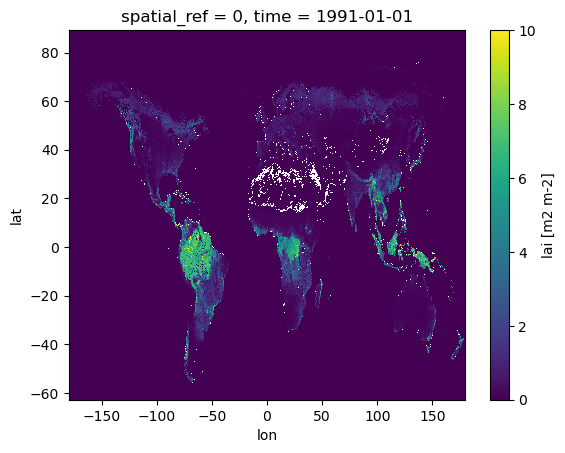

In [10]:
ds.lai.isel(time=0).plot()

In [11]:
client.close()
cluster.close()